
The sklearn.tree DecisionTreeClassifier learning algorithm allows for generating a useful and interprtable model for classification. This dataset will allow mapping of the symptoms to the corresponding diseases.

In [3]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

First, we load the training dataset. We will separate the features (symptoms) from the target variable (disease prognosis) and perform a train-test split on the "training" dataset. Since the symptoms are encoded as binary features, we can directly use them for training the decision tree model. The target variable is the 'prognosis' column, which contains the disease labels.

In [4]:
data_folder = "..\\data\\raw"
os.listdir(data_folder)

['Testing.csv', 'Training.csv']

In [5]:
#load the data

training_data = pd.read_csv(os.path.join(data_folder, "Training.csv"), index_col=False)
testing_data = pd.read_csv(os.path.join(data_folder, "Testing.csv"), index_col=False)

training_data.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


The column names in the dataset are the symptoms, and the values are binary (0 or 1) indicating the absence or presence of each symptom. The target variable is 'prognosis', which indicates the disease diagnosis based on the symptoms. 

In [68]:
# Select only the feature columns for clustering
feature_columns = training_data.columns[:-1]  # Assuming the last column is the target variable

# Extract the feature data
X = training_data[feature_columns]

y = training_data["prognosis"]


X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [52]:
#Initialize the model
dtc = DecisionTreeClassifier(random_state=42)

#Fit the model
dtc.fit(X_train, y_train)



DecisionTreeClassifier(random_state=42)

Next, the decision tree classifier is used with the test data set, and the accuracy of the predicted labels is evaluated by comparing to the true labels.

In [53]:
#Predict on the test data set
y_pred = dtc.predict(X_test)

#Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print (f"Accuracy:{accuracy:.2%}")


Accuracy:100.00%


To visualize the decision tree, we use the `plot_tree` function from the `sklearn.tree` module. The figure size is set to (80, 40) to accommodate the complexity of the tree.

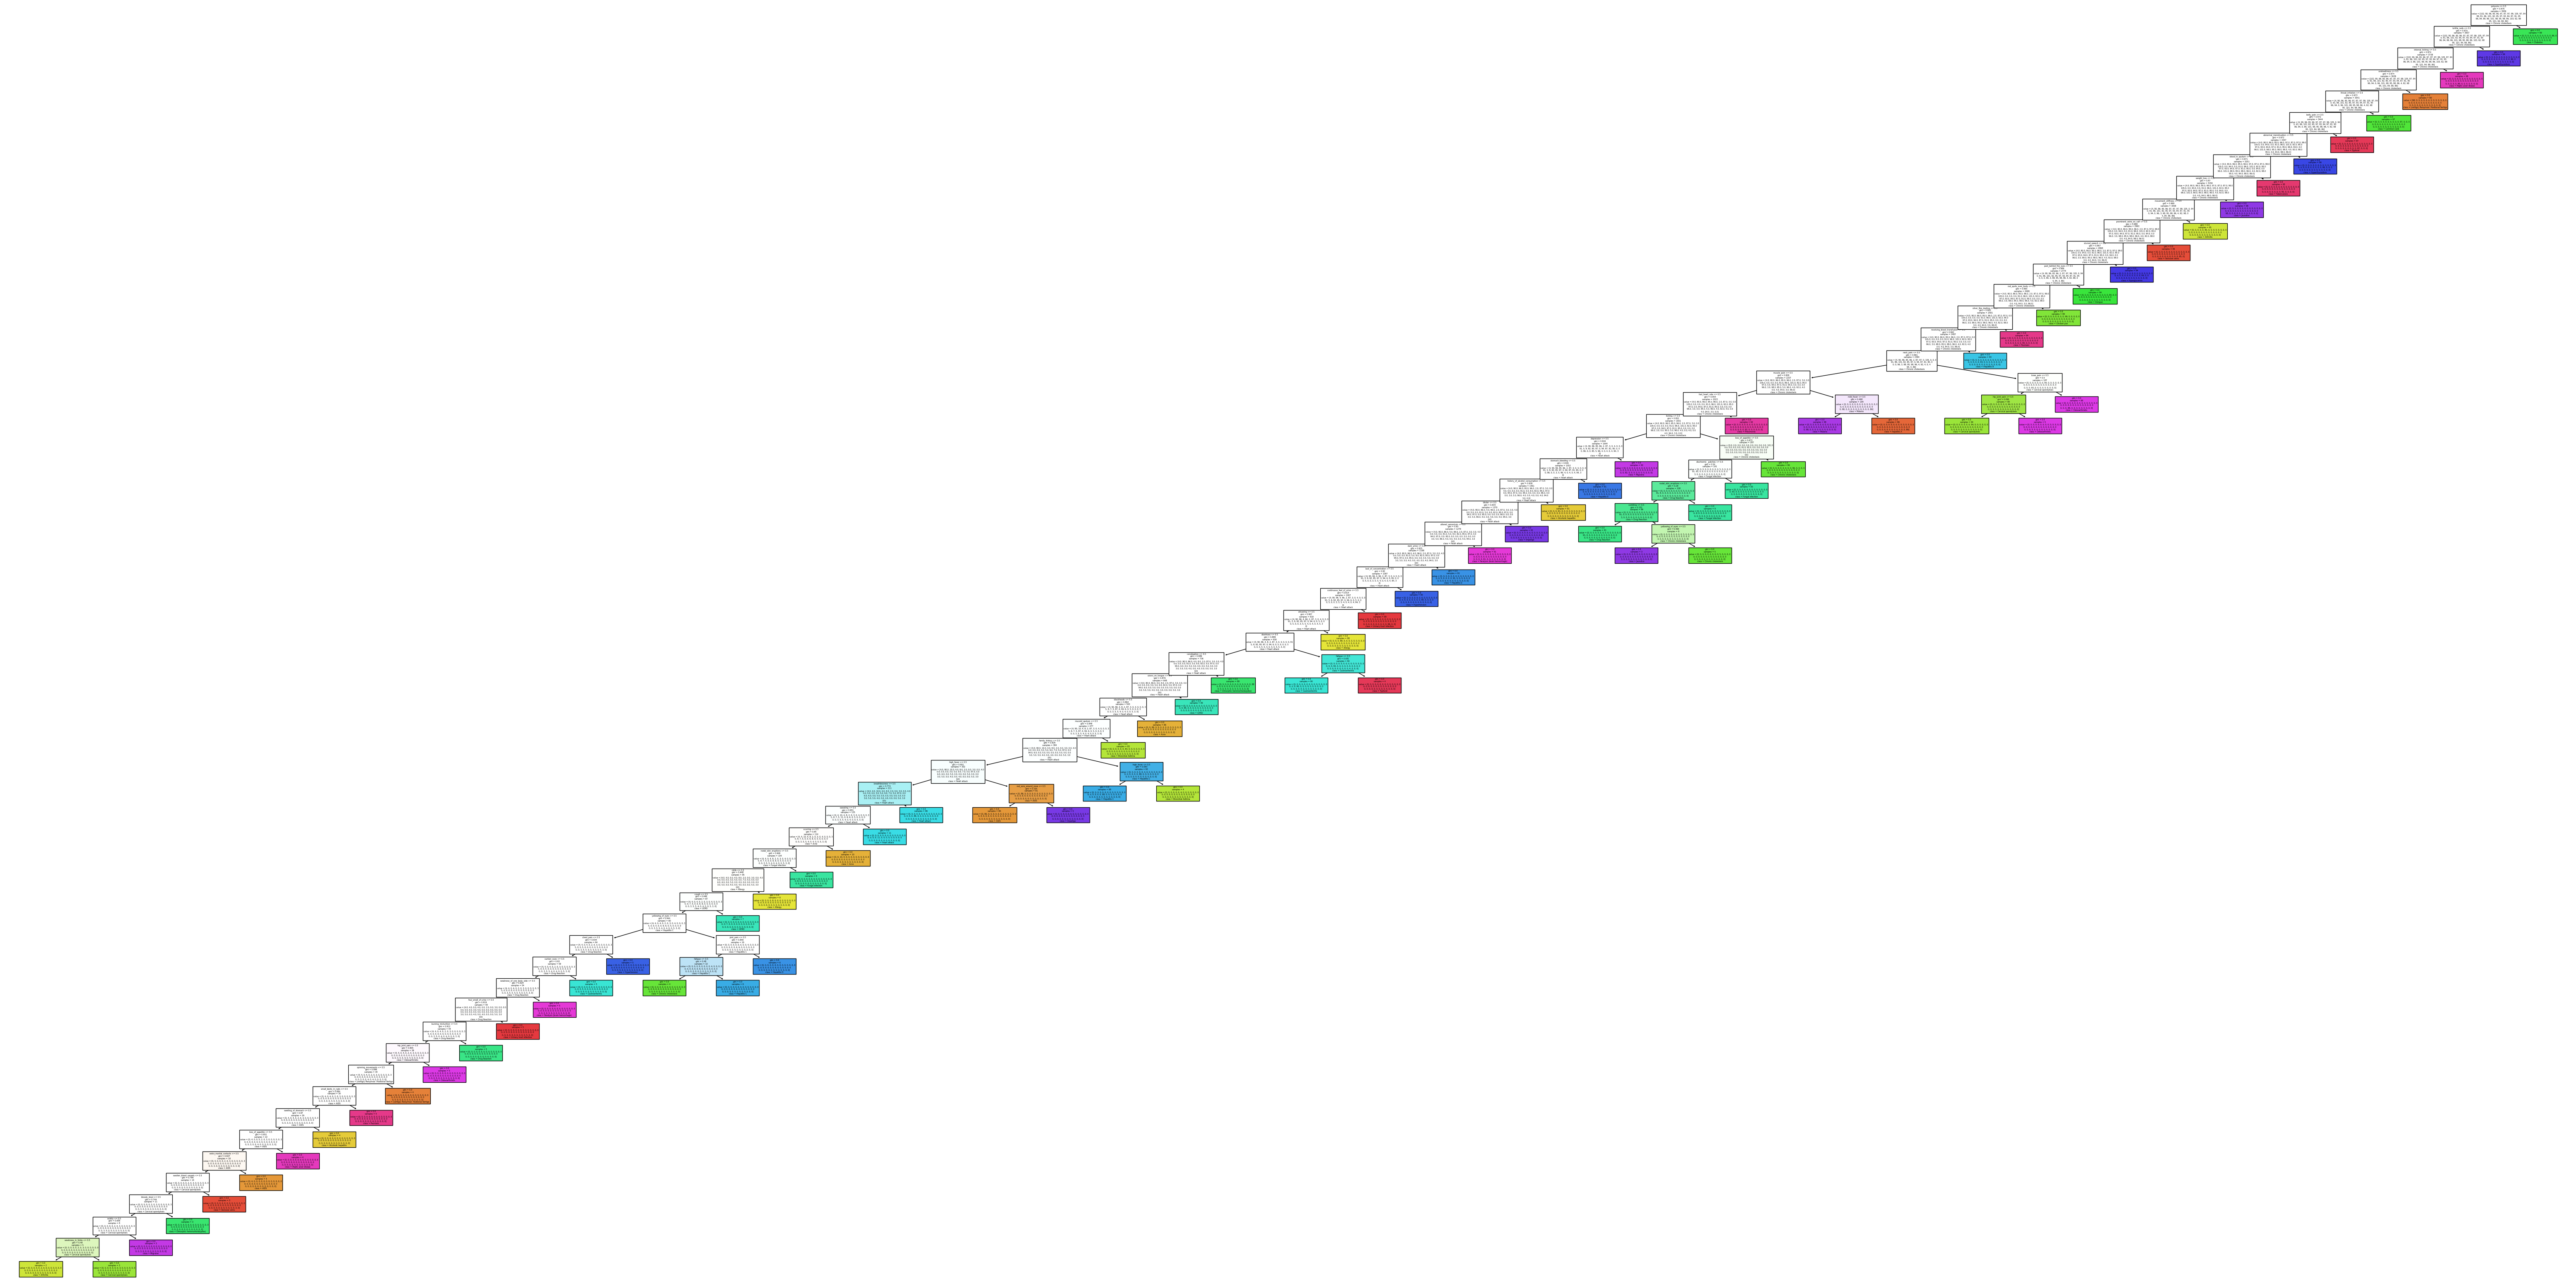

In [ ]:
# Visualizing the decision tree
class_names = sorted(training_data['prognosis'].unique())

plt.figure(figsize=(80,40))
plot_tree(dtc, filled=True, feature_names=X_test.columns, class_names=class_names)
plt.show()

#


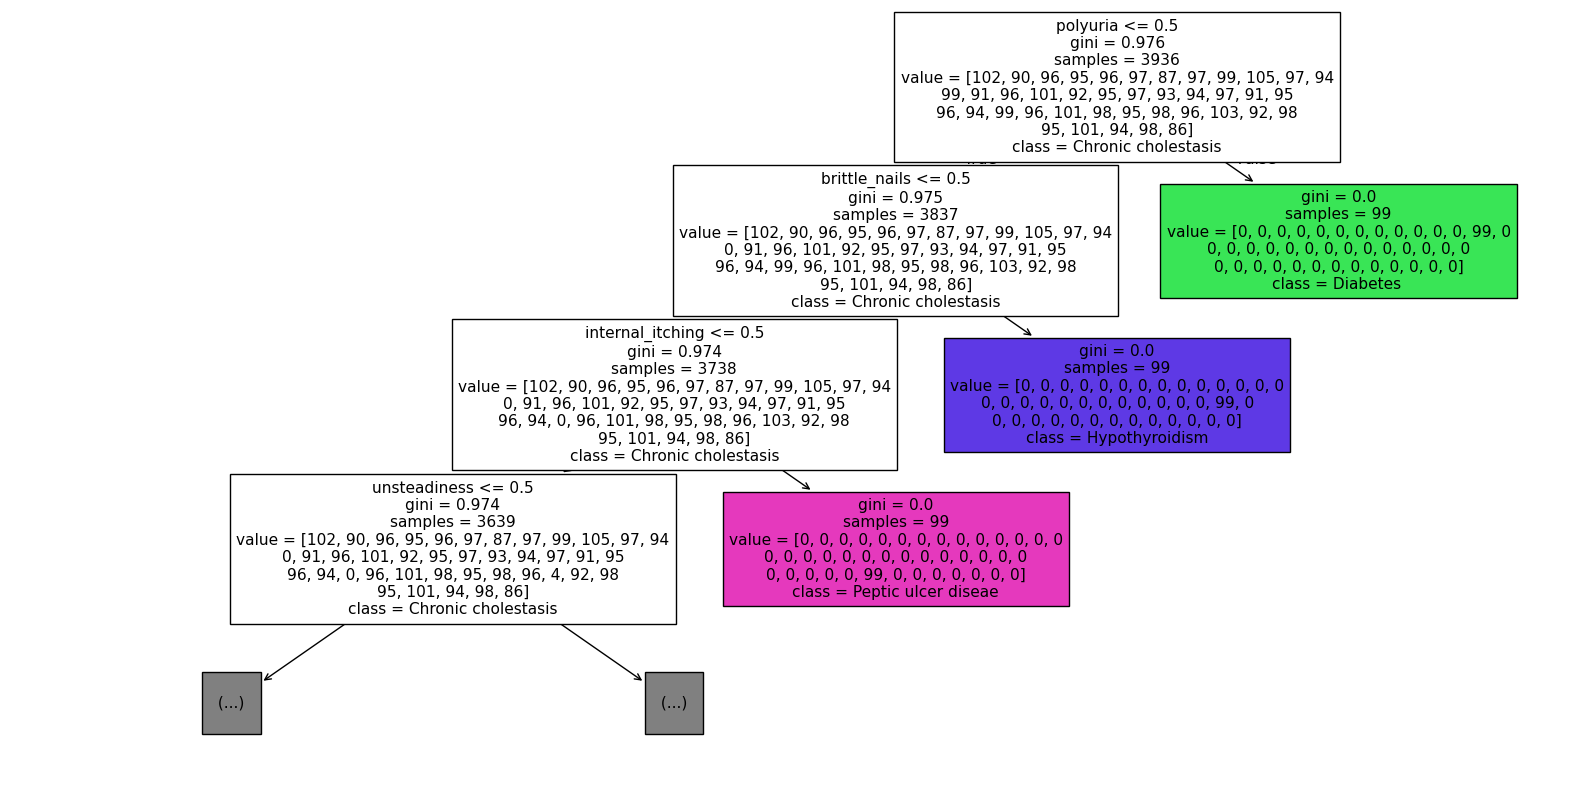

In [61]:
#zooming in on a specific part of the tree to better understand the decision rules at that node.
plt.figure(figsize=(20,10))
plot_tree(dtc, filled=True, feature_names=X_test.columns, class_names=class_names, max_depth=3)
plt.show()

We can see that the decision tree is making identical splits based on the presence or absence of the symptoms, which are represented as binary features in the dataset. The gini impurity at each node is zero, indicating that all the nodes are perfectly pure. This again reinforces the finding that this data is highly synthetic and not representative of real world data.

feature importance can be extracted from the decision tree model to understand which features are most influential in making predictions. 

In [66]:
feature_importances_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": dtc.feature_importances_
})
feature_importances_df = feature_importances_df.sort_values(by="importance", ascending=False)
feature_importances_df.head(10)

,feature,importance
105,polyuria,0.025763
72,brittle_nails,0.025762
99,red_spots_over_body,0.025737
93,internal_itching,0.025704
86,unsteadiness,0.025448
19,weight_loss,0.025447
51,throat_irritation,0.025250
100,belly_pain,0.025189
101,abnormal_menstruation,0.024994
118,blood_in_sputum,0.024741


All the features have near equal importance, which typically indicates that the model is learning the complex interplay of symptoms to make predictions, rather than relying heavily on a few key features. This is often a good sign that the model is capturing the underlying patterns in the data effectively.

The dataset also included a "Testing.csv" file, which we can use to evaluate the model's performance on unseen data. 

In [63]:
y_test_csv = testing_data["prognosis"]
X_test_csv = testing_data[feature_columns]
y_pred_csv = dtc.predict(X_test_csv)
accuracy_csv = accuracy_score(y_test_csv, y_pred_csv)
print (f"Accuracy on unseen data: {accuracy_csv:.2%}")


Accuracy on unseen data: 97.62%


THe accuracy on the unseen data is slightly lower than the accuracy on the test set, which is expected. Typically, this would suggest that the model is generalizing reasonably well to new data, but there may still be some overfitting to the training data.